In [ ]:
pip install torch torchvision matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 47.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
pip install tensorflow


Epoch [0/5], d_loss: 0.510926365852356, g_loss: 2.8673195838928223


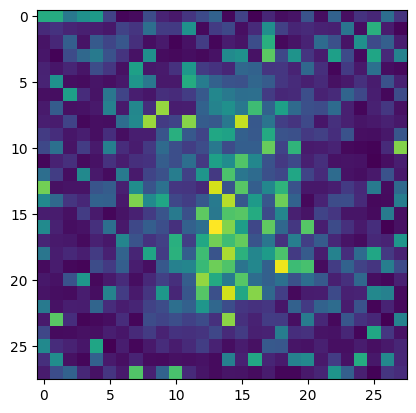

Epoch [1/5], d_loss: 0.31396040320396423, g_loss: 1.7348076105117798
Epoch [2/5], d_loss: 0.09010940790176392, g_loss: 4.59148645401001
Epoch [3/5], d_loss: 0.19930101931095123, g_loss: 2.4187469482421875
Epoch [4/5], d_loss: 0.3215517997741699, g_loss: 1.7802674770355225


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Check if GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the MNIST dataset and create DataLoader
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Define the Generator and Discriminator models as before

# Generator
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 784),
            nn.Tanh()  # Output values between -1 and 1 for image pixel intensities
        )

    def forward(self, z):
        return self.fc(z).view(z.size(0), 1, 28, 28)  # reshape output to 28x28 image

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output between 0 and 1
        )

    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))  # Flatten image to 1D

# Hyperparameters
z_dim = 100
batch_size = 64
lr = 0.0002
beta1 = 0.5  # For the Adam optimizer

# Create model instances and move to device
generator = Generator(z_dim).to(device)
discriminator = Discriminator().to(device)

# Binary cross-entropy loss
criterion = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(beta1, 0.999))

# Training loop
num_epochs = 5  # You can adjust this as needed

for epoch in range(num_epochs):
    for i, (real_images, _) in enumerate(train_loader):
        # Move real_images to the device
        real_images = real_images.to(device)

        # Get the actual batch size for this iteration (in case the batch is smaller than batch_size)
        batch_size = real_images.size(0)

        # Prepare real and fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train the Discriminator: real + fake
        optimizer_D.zero_grad()

        # Discriminator on real images
        output = discriminator(real_images)
        d_loss_real = criterion(output, real_labels)

        # Discriminator on fake images
        z = torch.randn(batch_size, z_dim).to(device)
        fake_images = generator(z)
        output = discriminator(fake_images.detach())  # Detach to avoid updating G
        d_loss_fake = criterion(output, fake_labels)

        # Total discriminator loss and backprop
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()

        # Train the Generator: try to fool the discriminator
        optimizer_G.zero_grad()

        output = discriminator(fake_images)
        g_loss = criterion(output, real_labels)  # Generator wants to fool the discriminator

        g_loss.backward()
        optimizer_G.step()

    # Print losses
    print(f'Epoch [{epoch}/{num_epochs}], d_loss: {d_loss.item()}, g_loss: {g_loss.item()}')

    # Optionally, save generated images
    if epoch % 10 == 0:
        fake_images = fake_images.cpu().detach().numpy()
        plt.imshow(np.transpose(fake_images[0], (1, 2, 0)))
        plt.show()


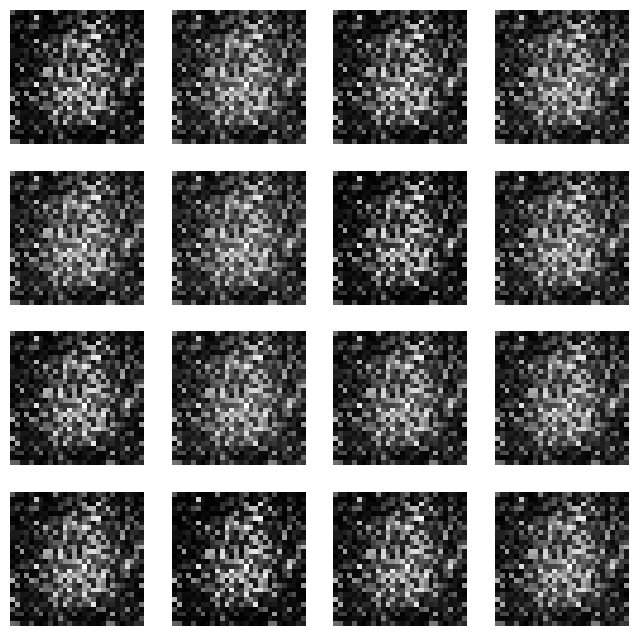

In [ ]:
# Generate a batch of images from random noise
z = torch.randn(16, z_dim).to(device)  # Generate 16 random noise vectors
generated_images = generator(z)

# Move images to CPU and convert to NumPy for plotting
generated_images = generated_images.cpu().detach().numpy()

# Plot the first image
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(np.transpose(generated_images[i], (1, 2, 0)), cmap='gray')
    plt.axis('off')
plt.show()
